In [ ]:
# ============================================================
# MODEL 7: ResNet101V2
# ============================================================

!pip -q install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# 1) Dataset Paths (Already split)
TRAIN_DIR = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Train"
TEST_DIR  = "/content/drive/MyDrive/Capstone Dataset/Guava_Leaf_Dieases/Test"

In [ ]:
# 2) Training Config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

In [ ]:
# 3) Load Dataset (Train/Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 4600 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Found 1150 files belonging to 5 classes.
Classes: ['Anthracnose', 'Canker', 'Dot', 'Healthy', 'Rust']


In [ ]:
# 4) Check Class Match
if val_ds.class_names != class_names:
    raise ValueError(f"Class mismatch.\nTrain: {class_names}\nTest : {val_ds.class_names}")

# 5) Data Pipeline Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# 6) Data Augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

In [ ]:
# 7) Build Model (Base + Head)
base = ResNet101V2(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
# 8) Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

In [ ]:
# 9) Train Head (Frozen Base)
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 2136s 3s/step - accuracy: 0.4485 - loss: 1.4444 - val_accuracy: 0.6078 - val_loss: 1.0247 - learning_rate: 0.0010
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - accuracy: 0.7007 - loss: 0.7886 - val_accuracy: 0.6591 - val_loss: 0.9441 - learning_rate: 0.0010
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - accuracy: 0.7666 - loss: 0.6534 - val_accuracy: 0.6791 - val_loss: 0.9544 - learning_rate: 0.0010
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 39s 273ms/step - accuracy: 0.7742 - loss: 0.6250 - val_accuracy: 0.6800 - val_loss: 0.9067 - learning_rate: 0.0010
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 39s 268ms/step - accuracy: 0.7802 - loss: 0.5931 - val_accuracy: 0.6739 - val_loss: 0.9229 - learning_rate: 0.0010


In [ ]:
# 10) Fine-tuning (Unfreeze Last Layers)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 73s 377ms/step - accuracy: 0.7614 - loss: 0.6789 - val_accuracy: 0.6817 - val_loss: 0.9113 - learning_rate: 1.0000e-05
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 46s 321ms/step - accuracy: 0.8543 - loss: 0.4190 - val_accuracy: 0.6835 - val_loss: 0.9028 - learning_rate: 1.0000e-05
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 328ms/step - accuracy: 0.8813 - loss: 0.3381 - val_accuracy: 0.7122 - val_loss: 0.8575 - learning_rate: 1.0000e-05
Epoch 4/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 46s 321ms/step - accuracy: 0.9109 - loss: 0.2633 - val_accuracy: 0.7191 - val_loss: 0.9106 - learning_rate: 1.0000e-05
Epoch 5/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 324ms/step - accuracy: 0.9308 - loss: 0.2173 - val_accuracy: 0.7139 - val_loss: 0.9416 - learning_rate: 1.0000e-05
Epoch 6/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 326ms/step - accuracy: 0.9294 - loss: 0.1946 - val_accuracy: 0.7148 - val_loss: 0.9684 - learning_rate: 5.0000e-06
Epoch 7/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 32

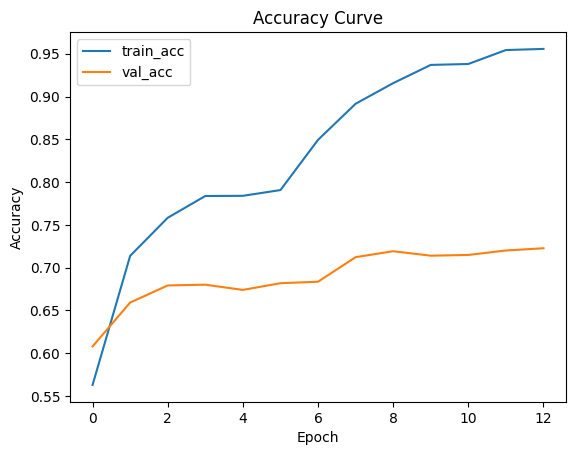

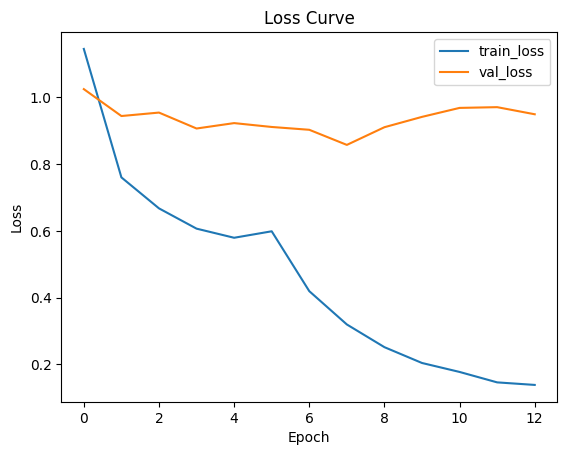

In [ ]:
# 11) Plot Training Curves
def plot_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure()
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_curves(h1, h2)

In [ ]:
# 12) Evaluate on Test
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Test Accuracy: 0.7122 | Test Loss: 0.8575


In [ ]:
# 13) Predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [ ]:
# 14) Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))



Classification Report:
              precision    recall  f1-score   support

 Anthracnose     0.6701    0.8478    0.7486       230
      Canker     0.8713    0.7652    0.8148       230
         Dot     0.5158    0.4261    0.4667       230
     Healthy     0.6767    0.8826    0.7660       230
        Rust     0.8802    0.6391    0.7406       230

    accuracy                         0.7122      1150
   macro avg     0.7228    0.7122    0.7073      1150
weighted avg     0.7228    0.7122    0.7073      1150



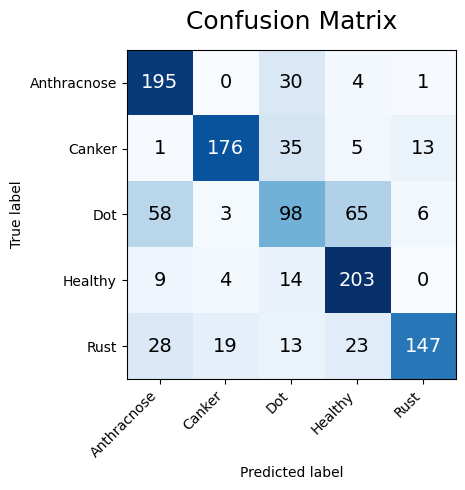

In [ ]:
# 15) Confusion Matrix (Blue style like your image, NO colorbar)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix", fontsize=18, pad=15)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=14, color="white" if cm[i, j] > thresh else "black")

ax.grid(False)
plt.tight_layout()
plt.show()

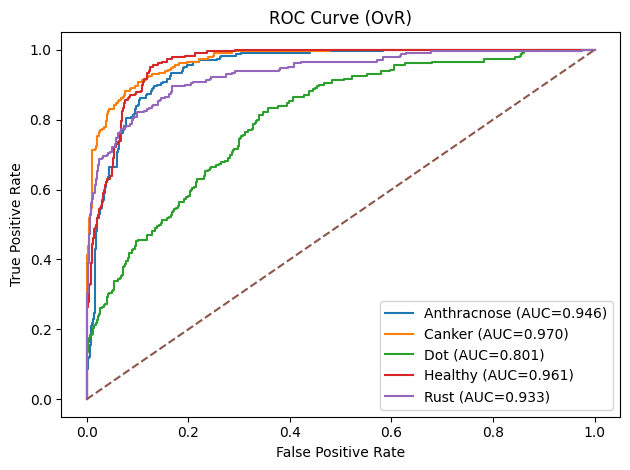

In [ ]:
# 16) ROC Curve (OvR)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 17) Save Model
import os
os.makedirs("/content/drive/MyDrive/Capstone Models", exist_ok=True)

model.save("/content/drive/MyDrive/Capstone Models/ResNet101V2_leaf.keras")
print("Model saved successfully.")

Model saved successfully.
